In [2]:
# Célula 1: Setup e Carregamento dos Dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path=Path("../.env"))

# Configs visuais
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

# Caminhos
PROC = Path("../data/processed")

# Conexão
DB_USER = "postgres"
DB_PASS = quote_plus(os.environ.get("DB_PASS", ""))
DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "pecuaria"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Carrega a tabela de performance direto do PostgreSQL
df = pd.read_sql("SELECT * FROM performance", con=engine)

print(f"{len(df)} animais carregados do PostgreSQL")
print(f"Colunas: {df.columns.tolist()}")
print(df.head(3))

500 animais carregados do PostgreSQL
Colunas: ['id_animal', 'brinco', 'raca', 'lote', 'peso_entrada', 'gmd_base', 'data_entrada', 'status', 'data_pesagem', 'peso_kg', 'gmd_periodo', 'arroba_atual', 'preco_arroba_rs', 'valor_mercado_rs', 'dias_conf', 'custo_sanitario_rs', 'custo_racao_lote_rs', 'n_animais_lote', 'custo_racao_animal_rs', 'gmd_total', 'ganho_peso_kg', 'custo_total_animal_rs', 'custo_por_kg_ganho', 'margem_bruta_rs', 'conversao_alimentar', 'classe_performance']
   id_animal  brinco            raca  lote  peso_entrada  gmd_base  \
0          1  BR0001          Nelore     3         257.8     1.114   
1          2  BR0002          Nelore     8         239.8     0.951   
2          3  BR0003  Cruzado Nelore     5         285.6     1.253   

  data_entrada status data_pesagem  peso_kg  ...  custo_racao_lote_rs  \
0   2024-07-01  ativo   2025-02-10    534.5  ...            222144.47   
1   2024-07-01  ativo   2025-04-07    529.9  ...            239916.02   
2   2024-07-01  ativo

In [3]:
# Célula 2: Seleção de Features e Pré-Processamento
print("--- PREPARANDO FEATURES PARA CLUSTERING ---")

# Features que capturam performance real do animal
features = [
    'gmd_total',             # velocidade de crescimento
    'conversao_alimentar',   # eficiência alimentar
    'custo_por_kg_ganho',    # custo de produção
    'margem_bruta_rs',       # lucratividade
    'peso_entrada',          # peso inicial
    'dias_conf',             # tempo em confinamento
]

df_cluster = df[features].copy()

# Verificar nulos
print(f"Nulos por coluna:\n{df_cluster.isnull().sum()}")

# Normaliza com StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df_cluster)
X_df = pd.DataFrame(X, columns=features)

print(f"\nBase normalizada: {X_df.shape}")
print(f"Média após normalização (deve ser ~0):")
print(X_df.mean().round(4))

--- PREPARANDO FEATURES PARA CLUSTERING ---
Nulos por coluna:
gmd_total              0
conversao_alimentar    0
custo_por_kg_ganho     0
margem_bruta_rs        0
peso_entrada           0
dias_conf              0
dtype: int64

Base normalizada: (500, 6)
Média após normalização (deve ser ~0):
gmd_total              0.0
conversao_alimentar    0.0
custo_por_kg_ganho     0.0
margem_bruta_rs       -0.0
peso_entrada           0.0
dias_conf             -0.0
dtype: float64


In [4]:
# Célula 3: Experimentos K-Means
print("--- K-MEANS: k=2 a 10 ---")

resultados_kmeans = {
    'k': [],
    'silhouette_kpp': [], 'db_kpp': [],
    'silhouette_random': [], 'db_random': []
}

for k in range(2, 11):
    # k-means++
    km_kpp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_kpp = km_kpp.fit_predict(X)

    # random
    km_rnd = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    labels_rnd = km_rnd.fit_predict(X)

    resultados_kmeans['k'].append(k)
    resultados_kmeans['silhouette_kpp'].append(silhouette_score(X, labels_kpp))
    resultados_kmeans['db_kpp'].append(davies_bouldin_score(X, labels_kpp))
    resultados_kmeans['silhouette_random'].append(silhouette_score(X, labels_rnd))
    resultados_kmeans['db_random'].append(davies_bouldin_score(X, labels_rnd))

    print(f"k={k} ✓")

df_kmeans = pd.DataFrame(resultados_kmeans)
print(f"\nK-Means concluído")
print(df_kmeans[['k','silhouette_kpp','db_kpp']].to_string(index=False))

--- K-MEANS: k=2 a 10 ---
k=2 ✓
k=3 ✓
k=4 ✓
k=5 ✓
k=6 ✓
k=7 ✓
k=8 ✓
k=9 ✓
k=10 ✓

K-Means concluído
 k  silhouette_kpp   db_kpp
 2        0.327128 1.147007
 3        0.282441 1.263399
 4        0.295956 1.115552
 5        0.290309 1.112897
 6        0.289913 1.071797
 7        0.287679 1.034883
 8        0.284843 1.065461
 9        0.297992 1.058309
10        0.306240 1.004679


In [5]:
# Célula 4: Experimentos Hierárquico
print("--- HIERÁRQUICO: k=2 a 10 ---")

resultados_hc = {'k': [], 'linkage': [], 'silhouette': [], 'db': []}
linkages = ['ward', 'complete', 'average', 'single']

for k in range(2, 11):
    for link in linkages:
        hc = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = hc.fit_predict(X)
        resultados_hc['k'].append(k)
        resultados_hc['linkage'].append(link)
        resultados_hc['silhouette'].append(silhouette_score(X, labels))
        resultados_hc['db'].append(davies_bouldin_score(X, labels))
    print(f"k={k} ✓")

df_hc = pd.DataFrame(resultados_hc)
print(f"\nHierárquico concluído")
print(df_hc[df_hc['linkage']=='ward'][['k','silhouette','db']].to_string(index=False))

--- HIERÁRQUICO: k=2 a 10 ---
k=2 ✓
k=3 ✓
k=4 ✓
k=5 ✓
k=6 ✓
k=7 ✓
k=8 ✓
k=9 ✓
k=10 ✓

Hierárquico concluído
 k  silhouette       db
 2    0.344707 1.058989
 3    0.289340 1.369426
 4    0.306412 1.110495
 5    0.289367 1.120975
 6    0.264262 1.079652
 7    0.267036 1.081576
 8    0.271968 1.087530
 9    0.291531 1.083248
10    0.297447 1.112715


In [6]:
# Célula 5: Final Score e escolha objetiva do k
print("--- FINAL SCORE ---")

# ── K-Means ──────────────────────────────────────────────────────────────
df_kmeans['sil_best'] = df_kmeans[['silhouette_kpp','silhouette_random']].max(axis=1)
df_kmeans['db_best']  = df_kmeans[['db_kpp','db_random']].min(axis=1)

df_kmeans['sil_norm'] = (df_kmeans['sil_best'] - df_kmeans['sil_best'].min()) / \
                         (df_kmeans['sil_best'].max() - df_kmeans['sil_best'].min())
df_kmeans['db_norm']  = 1 - (df_kmeans['db_best'] - df_kmeans['db_best'].min()) / \
                             (df_kmeans['db_best'].max() - df_kmeans['db_best'].min())
df_kmeans['final_score'] = (df_kmeans['sil_norm'] + df_kmeans['db_norm']) / 2

venc_km = df_kmeans.loc[df_kmeans['final_score'].idxmax()]
print(f"K-Means vencedor: k={int(venc_km['k'])} | Score={venc_km['final_score']:.4f}")
print(df_kmeans[['k','sil_best','db_best','final_score']].to_string(index=False))

# ── Hierárquico ───────────────────────────────────────────────────────────
print()
df_hc['sil_norm'] = (df_hc['silhouette'] - df_hc['silhouette'].min()) / \
                     (df_hc['silhouette'].max() - df_hc['silhouette'].min())
df_hc['db_norm']  = 1 - (df_hc['db'] - df_hc['db'].min()) / \
                         (df_hc['db'].max() - df_hc['db'].min())
df_hc['final_score'] = (df_hc['sil_norm'] + df_hc['db_norm']) / 2

venc_hc = df_hc.loc[df_hc['final_score'].idxmax()]
print(f"Hierárquico vencedor: k={int(venc_hc['k'])}, linkage={venc_hc['linkage']} | Score={venc_hc['final_score']:.4f}")
print(df_hc.nlargest(5,'final_score')[['k','linkage','silhouette','db','final_score']].to_string(index=False))

--- FINAL SCORE ---
K-Means vencedor: k=10 | Score=0.7580
 k  sil_best  db_best  final_score
 2  0.327128 1.147007     0.720832
 3  0.283976 1.259594     0.000000
 4  0.296673 1.115552     0.429655
 5  0.290309 1.112897     0.361119
 6  0.289913 1.071797     0.437150
 7  0.287679 1.034883     0.483667
 8  0.284843 1.058180     0.405110
 9  0.301599 1.058309     0.599010
10  0.306240 1.004679     0.757971

Hierárquico vencedor: k=3, linkage=single | Score=0.9637
 k linkage  silhouette       db  final_score
 3  single    0.544044 0.310721     0.963719
 4  single    0.514058 0.296193     0.929382
 2 average    0.565572 0.502682     0.903800
 2  single    0.565572 0.502682     0.903800
 5  single    0.465374 0.344792     0.840003


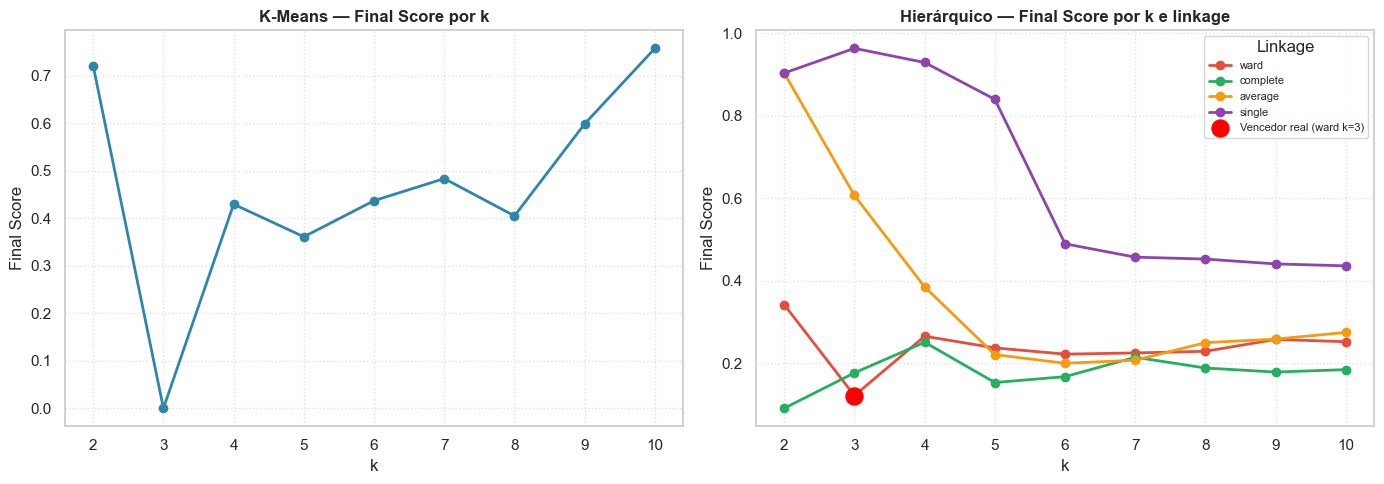

Gráfico salvo!

Distribuição dos clusters:
cluster
0    118
1    132
2    250
Name: count, dtype: int64

Perfil médio por cluster:
         gmd_total  conversao_alimentar  custo_por_kg_ganho  margem_bruta_rs
cluster                                                                     
0             1.62                 3.61               24.11           738.59
1             0.93                 6.38               19.47           507.87
2             1.32                 4.38               20.46           652.80


In [7]:
# Célula 6: Gráfico Final Score + Modelo Vencedor (ward k=3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico K-Means
axes[0].plot(df_kmeans['k'], df_kmeans['final_score'],
             marker='o', color='#2E86AB', linewidth=2)
axes[0].set_title('K-Means — Final Score por k', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Final Score')
axes[0].set_xticks(range(2, 11))
axes[0].grid(True, linestyle=':', alpha=0.6)

# Gráfico Hierárquico
for link, cor in zip(['ward','complete','average','single'],
                     ['#E74C3C','#27AE60','#F39C12','#8E44AD']):
    subset = df_hc[df_hc['linkage'] == link]
    axes[1].plot(subset['k'], subset['final_score'],
                 marker='o', label=link, color=cor, linewidth=2)

# Destaca o vencedor real (ward, k=3)
ward_k3 = df_hc[(df_hc['linkage']=='ward') & (df_hc['k']==3)]['final_score'].values[0]
axes[1].scatter([3], [ward_k3], color='red', s=150, zorder=5,
                label='Vencedor real (ward k=3)')
axes[1].set_title('Hierárquico — Final Score por k e linkage', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Final Score')
axes[1].set_xticks(range(2, 11))
axes[1].legend(title='Linkage', fontsize=8)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(Path('../data/processed') / 'grafico_final_score_pecuaria.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico salvo!")

# ── Modelo vencedor: Hierárquico ward k=3 ────────────────────────────────
hc_final = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['cluster'] = hc_final.fit_predict(X)

print(f"\nDistribuição dos clusters:")
print(df['cluster'].value_counts().sort_index())

print(f"\nPerfil médio por cluster:")
print(df.groupby('cluster')[
    ['gmd_total','conversao_alimentar',
     'custo_por_kg_ganho','margem_bruta_rs']
].mean().round(2))

--- NOMEANDO CLUSTERS ---
Distribuição por nome:
cluster_nome
Performance Média    250
Baixa Performance    132
Alta Performance     118
Name: count, dtype: int64

Variância explicada pelos 3 componentes: 97.4%


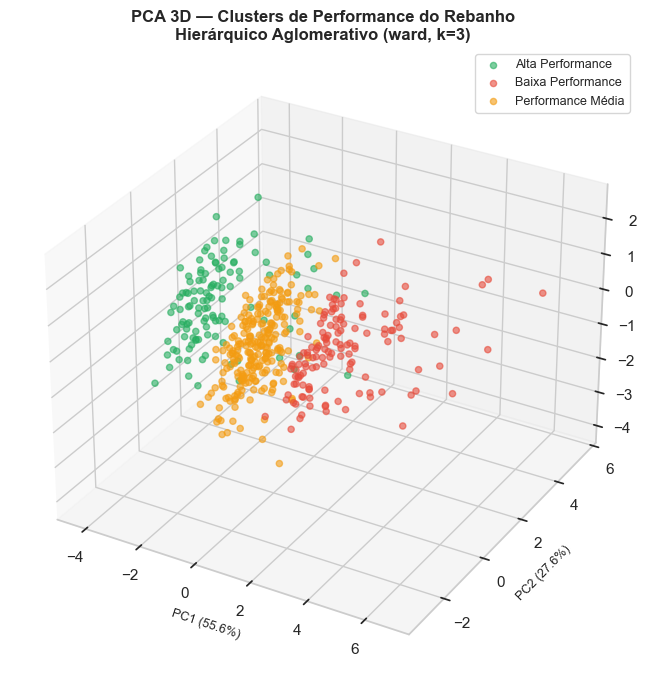

PCA 3D salvo!


In [8]:
# Célula 7: Nomeação de Clusters e PCA 3D
print("--- NOMEANDO CLUSTERS ---")

# Mapa de nomes baseado no perfil
nomes_cluster = {
    0: "Alta Performance",
    1: "Baixa Performance",
    2: "Performance Média"
}

df['cluster_nome'] = df['cluster'].map(nomes_cluster)

print("Distribuição por nome:")
print(df['cluster_nome'].value_counts())

# ── PCA 3D ────────────────────────────────────────────────────────────────
pca = PCA(n_components=3, random_state=42)
coords = pca.fit_transform(X)
variancia = pca.explained_variance_ratio_
print(f"\nVariância explicada pelos 3 componentes: {variancia.sum()*100:.1f}%")

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

cores = {0: '#27AE60', 1: '#E74C3C', 2: '#F39C12'}
for cluster_id, nome in nomes_cluster.items():
    mask = df['cluster'] == cluster_id
    ax.scatter(
        coords[mask, 0], coords[mask, 1], coords[mask, 2],
        c=cores[cluster_id], s=20, alpha=0.6, label=nome
    )

ax.set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)', fontsize=9)
ax.set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)', fontsize=9)
ax.set_zlabel(f'PC3 ({variancia[2]*100:.1f}%)', fontsize=9)
ax.set_title('PCA 3D — Clusters de Performance do Rebanho\nHierárquico Aglomerativo (ward, k=3)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(Path('../data/processed') / 'grafico_pca3d_pecuaria.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("PCA 3D salvo!")

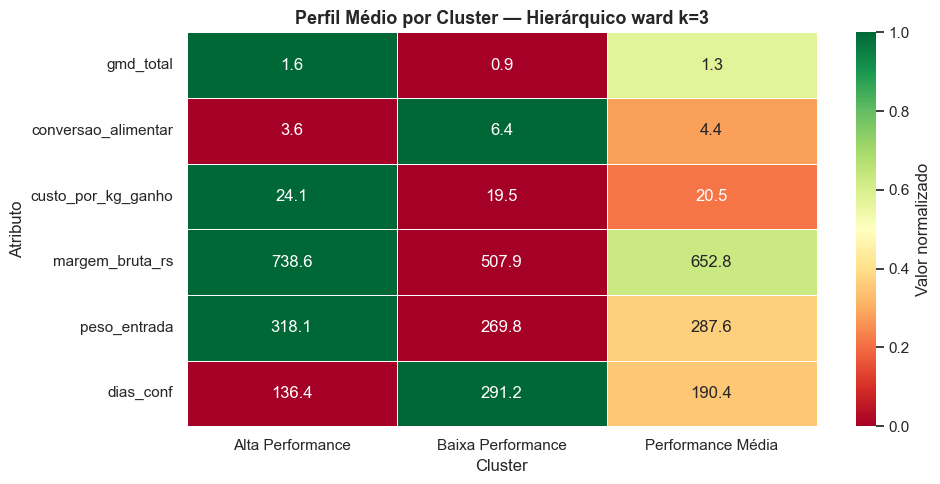

Heatmap salvo!
Tabela clusters_rebanho salva no PostgreSQL!
CSV salvo!


In [10]:
# Célula 8: Heatmap de perfil + salvamento
fig, ax = plt.subplots(figsize=(10, 5))

perfil = df.groupby('cluster_nome')[
    ['gmd_total','conversao_alimentar',
     'custo_por_kg_ganho','margem_bruta_rs',
     'peso_entrada','dias_conf']
].mean()

# Normaliza pra heatmap
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())

sns.heatmap(
    perfil_norm.T,
    ax=ax,
    cmap='RdYlGn',
    annot=perfil.T.round(1),
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Valor normalizado'}
)

ax.set_title('Perfil Médio por Cluster — Hierárquico ward k=3',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Atributo')
ax.set_xlabel('Cluster')

plt.tight_layout()
plt.savefig(Path('../data/processed') / 'grafico_heatmap_pecuaria.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Heatmap salvo!")

# ── Salva resultado com clusters no PostgreSQL ────────────────────────────
df[['id_animal','brinco','cluster','cluster_nome']].to_sql(
    'clusters_rebanho',
    con=engine,
    if_exists='replace',
    index=False
)
print("Tabela clusters_rebanho salva no PostgreSQL!")

# Salva CSV também
df.to_csv(Path('../data/processed') / 'performance_com_clusters.csv', index=False)
print("CSV salvo!")